In [1]:
!pip install -q datasets transformers sentence-transformers scikit-learn pandas numpy matplotlib tqdm statsmodels

In [19]:
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_distances
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [9]:
# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("hfht/SemEval-2021-Task-7-Jokes", "train")

train = ds["train"].to_pandas()
dev = ds["validation"].to_pandas() if "validation" in ds else None

df = train.copy()
print(df.columns)
df.head()

hahackathon_train.csv:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Index(['id', 'text', 'is_humor', 'humor_rating', 'humor_controversy',
       'offense_rating'],
      dtype='object')


,id,text,is_humor,humor_rating,humor_controversy,offense_rating
0,1,TENNESSEE: We're the best state. Nobody even c...,1,2.42,1.0,0.2
1,2,A man inserted an advertisement in the classif...,1,2.50,1.0,1.1
2,3,How many men does it take to open a can of bee...,1,1.95,0.0,2.4
3,4,Told my mom I hit 1200 Twitter followers. She ...,1,2.11,1.0,0.0
4,5,Roses are dead. Love is fake. Weddings are bas...,1,2.78,0.0,0.1


In [10]:
for c in df.columns:
    print(c, df[c].head(3).tolist())

id [1, 2, 3]
text ["TENNESSEE: We're the best state. Nobody even comes close. *Elevennessee walks into the room* TENNESSEE: Oh shit...", 'A man inserted an advertisement in the classifieds "Wife Wanted". The next day, he received 1000 of replies, all reading: "You can have mine." Free delivery also available at your door step', 'How many men does it take to open a can of beer? None. It should be open by the time she brings it to the couch.']
is_humor [1, 1, 1]
humor_rating [2.42, 2.5, 1.95]
humor_controversy [1.0, 1.0, 0.0]
offense_rating [0.2, 1.1, 2.4]


In [11]:
text_col = "text"
rating_col = "humor_rating"

In [12]:
df = df[[text_col, rating_col]].dropna()
df = df.rename(columns={text_col: "text", rating_col: "funniness"})
df = df[df["funniness"].astype(float) > 0]  # optional: keep humorous examples
df["funniness"] = df["funniness"].astype(float)

df = df.sample(min(1000, len(df)), random_state=42).reset_index(drop=True)
df.head()

,text,funniness
0,So my girlfriend just told me that she needed ...,2.50
1,When I found out my toaster wasn't waterproof....,2.40
2,I like when the shoe salesman puts the shoe on...,1.93
3,It is said that the Welsh were the first to us...,2.80
4,What do u call a hilarious Mexican herb? Silly...,1.89


In [14]:
!pip install -q transformers torch

In [16]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

lm_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(lm_name)
lm = AutoModelForCausalLM.from_pretrained(lm_name).to(
    "cuda" if torch.cuda.is_available() else "cpu"
)
lm.eval()

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [17]:
def lm_features(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(lm.device)

    with torch.no_grad():
        out = lm(**inputs)
        logits = out.logits[:, :-1, :]
        labels = inputs["input_ids"][:, 1:]

        probs = torch.softmax(logits, dim=-1)
        token_probs = probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)

        surprisal = -torch.log(token_probs + 1e-12).mean().item()
        entropy = -(probs * torch.log(probs + 1e-12)).sum(dim=-1).mean().item()

    return surprisal, entropy

In [26]:
import re
from sklearn.metrics.pairwise import cosine_distances
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")

def split_setup_punchline(text):
    text = str(text).strip()

    # Split after sentence-ending punctuation
    parts = re.split(r'(?<=[.!?])\s+', text)

    # Keep only non-empty parts
    parts = [p.strip() for p in parts if p.strip()]

    # If there are at least 2 sentence-like parts,
    # use everything before the last sentence as setup,
    # and the last sentence as punchline.
    if len(parts) >= 2:
        setup = " ".join(parts[:-1])
        punchline = parts[-1]
        return setup, punchline

    # Fallback: split by semicolon/colon/dash if present
    parts = re.split(r'\s*[;:—–-]\s+', text)
    parts = [p.strip() for p in parts if p.strip()]

    if len(parts) >= 2:
        setup = " ".join(parts[:-1])
        punchline = parts[-1]
        return setup, punchline

    # Final fallback: split by word midpoint
    words = text.split()
    if len(words) < 4:
        return text, text

    mid = len(words) // 2
    setup = " ".join(words[:mid])
    punchline = " ".join(words[mid:])
    return setup, punchline


def embed_distance(text):
    setup, punchline = split_setup_punchline(text)

    emb = embedder.encode([setup, punchline])
    return cosine_distances([emb[0]], [emb[1]])[0, 0]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
surprisals, entropies, distances = [], [], []

for text in tqdm(df["text"]):
    s, h = lm_features(text)
    d = embed_distance(text)

    surprisals.append(s)
    entropies.append(h)
    distances.append(d)

df["surprisal"] = surprisals
df["entropy"] = entropies
df["embedding_distance"] = distances

df.head()

100%|██████████| 1000/1000 [05:13<00:00,  3.19it/s]


,text,funniness,surprisal,entropy,embedding_distance
0,So my girlfriend just told me that she needed ...,2.50,3.696633,4.157878,0.614013
1,When I found out my toaster wasn't waterproof....,2.40,3.962320,4.104514,0.860062
2,I like when the shoe salesman puts the shoe on...,1.93,3.977849,4.154584,0.516051
3,It is said that the Welsh were the first to us...,2.80,3.441046,4.514703,0.425070
4,What do u call a hilarious Mexican herb? Silly...,1.89,6.762397,5.740389,0.704450


In [28]:
features = ["surprisal", "entropy", "embedding_distance"]

X_raw = df[features].values
y = df["funniness"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

S = X_scaled[:, 0]
H = X_scaled[:, 1]
D = X_scaled[:, 2]

X_quad = pd.DataFrame({
    "S": S,
    "S2": S**2,
    "H": H,
    "H2": H**2,
    "D": D,
    "D2": D**2,
})

X_quad = sm.add_constant(X_quad)

model = sm.OLS(y, X_quad).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     16.84
Date:                Fri, 29 May 2026   Prob (F-statistic):           1.42e-18
Time:                        21:40:40   Log-Likelihood:                -814.42
No. Observations:                1000   AIC:                             1643.
Df Residuals:                     993   BIC:                             1677.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3256      0.026     90.429      0.0

In [29]:
coefs = model.params

for name, linear, quad in [
    ("surprisal", "S", "S2"),
    ("entropy", "H", "H2"),
    ("embedding_distance", "D", "D2")
]:
    b1 = coefs[linear]
    b2 = coefs[quad]

    print("\n", name)
    print("linear coef:", b1)
    print("quadratic coef:", b2)

    if b2 < 0:
        peak = -b1 / (2 * b2)
        print("Inverted-U supported. Peak at standardized value:", peak)
    else:
        print("Not inverted-U. Quadratic term is not negative.")


 surprisal
linear coef: -0.13973917950143633
quadratic coef: 0.004524675698738004
Not inverted-U. Quadratic term is not negative.

 entropy
linear coef: -0.027118990253769737
quadratic coef: -0.012362927937359408
Inverted-U supported. Peak at standardized value: -1.0967867155408684

 embedding_distance
linear coef: -0.042991752937057204
quadratic coef: -0.02963017000799651
Inverted-U supported. Peak at standardized value: -0.7254725998105092


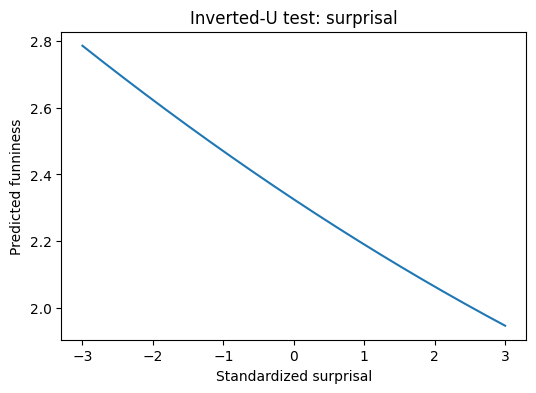

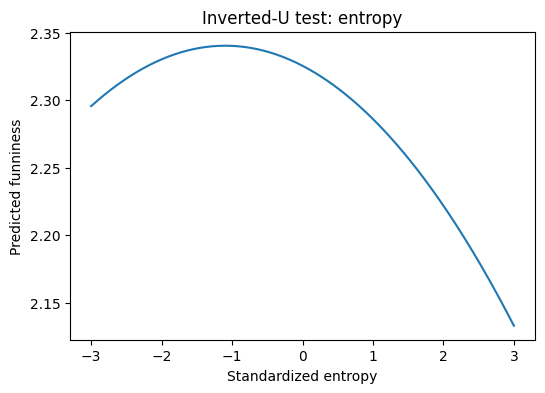

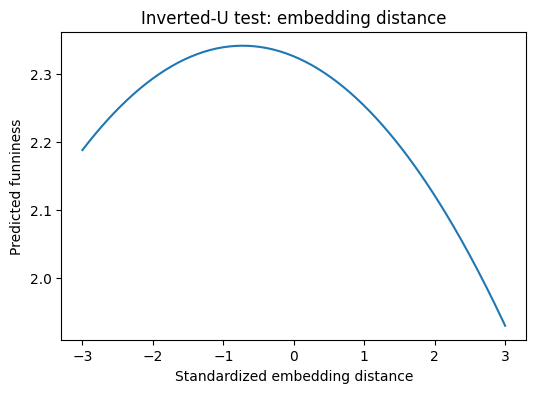

In [30]:
def plot_quadratic(feature_name, linear_name, quad_name):
    x = np.linspace(-3, 3, 200)
    b0 = model.params["const"]
    b1 = model.params[linear_name]
    b2 = model.params[quad_name]

    y_pred = b0 + b1*x + b2*x**2

    plt.figure(figsize=(6,4))
    plt.plot(x, y_pred)
    plt.xlabel(f"Standardized {feature_name}")
    plt.ylabel("Predicted funniness")
    plt.title(f"Inverted-U test: {feature_name}")
    plt.show()

plot_quadratic("surprisal", "S", "S2")
plot_quadratic("entropy", "H", "H2")
plot_quadratic("embedding distance", "D", "D2")

In [31]:
print("R^2:", model.rsquared)
print("Adjusted R^2:", model.rsquared_adj)

R^2: 0.09233564538749472
Adjusted R^2: 0.0868512686224645


reddit dataset

In [32]:
!git clone https://github.com/orionw/rJokesData.git

Cloning into 'rJokesData'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 80 (delta 3), reused 0 (delta 0), pack-reused 71 (from 1)
Receiving objects: 100% (80/80), 201.50 MiB | 32.64 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Updating files: 100% (63/63), done.


In [33]:
import os

for root, dirs, files in os.walk("rJokesData"):
    for f in files:
        print(os.path.join(root, f))

rJokesData/README.md
rJokesData/.gitignore
rJokesData/requirements.txt
rJokesData/download_nltk_packages.sh
rJokesData/analysis/run_glue.py
rJokesData/analysis/regression_results_large.csv
rJokesData/analysis/time_statistics.py
rJokesData/analysis/gather_regression.py
rJokesData/analysis/regression-base.sh
rJokesData/analysis/regression_results_base.csv
rJokesData/analysis/dataset_statistics.py
rJokesData/analysis/regression-large.sh
rJokesData/.git/index
rJokesData/.git/description
rJokesData/.git/packed-refs
rJokesData/.git/HEAD
rJokesData/.git/config
rJokesData/.git/logs/HEAD
rJokesData/.git/logs/refs/heads/master
rJokesData/.git/logs/refs/remotes/origin/HEAD
rJokesData/.git/hooks/pre-commit.sample
rJokesData/.git/hooks/post-update.sample
rJokesData/.git/hooks/pre-push.sample
rJokesData/.git/hooks/push-to-checkout.sample
rJokesData/.git/hooks/commit-msg.sample
rJokesData/.git/hooks/fsmonitor-watchman.sample
rJokesData/.git/hooks/update.sample
rJokesData/.git/hooks/pre-receive.sample

In [38]:
import pandas as pd
import numpy as np

reddit_df = pd.read_csv("rJokesData/data/preprocessed.csv.gz")

print(reddit_df.shape)
print(reddit_df.columns)
reddit_df.head()

(573408, 5)
Index(['joke', 'body', 'punchline', 'score', 'date'], dtype='object')


,joke,body,punchline,score,date
0,A Day in Court,NaN,A Day in Court,5.0,1.201282e+09
1,Photograph of Software project Team,NaN,Photograph of Software project Team,0.0,1.202643e+09
2,what we guys really like,NaN,what we guys really like,3.0,1.202651e+09
3,The Nietzsche Family Circus random generator,NaN,The Nietzsche Family Circus random generator,3.0,1.204249e+09
4,funny pic: His & Hers SUV,NaN,funny pic: His & Hers SUV,0.0,1.206129e+09


In [39]:
text_col = "body"      # or "text", "joke"
score_col = "score"    # or "ups", "upvotes"

In [40]:
reddit_df = reddit_df[[text_col, score_col]].dropna()
reddit_df = reddit_df.rename(columns={
    text_col: "text",
    score_col: "funniness"
})

reddit_df["funniness"] = pd.to_numeric(reddit_df["funniness"], errors="coerce")
reddit_df = reddit_df.dropna()

# Reddit scores are very skewed, so log-transform
import numpy as np
reddit_df = reddit_df[reddit_df["funniness"] > 0]
reddit_df["funniness"] = np.log1p(reddit_df["funniness"])

# sample for speed
reddit_df = reddit_df.sample(min(3000, len(reddit_df)), random_state=42).reset_index(drop=True)
reddit_df.head()

,text,funniness
0,Hindsight is 2020.,1.945910
1,"""Ow""",1.386294
2,3 blondes die and go to heaven. Before they ca...,5.463832
3,"“When the day of Pentecost came, they were all...",2.772589
4,"In other words, there's joint support for join...",4.584967


In [41]:
df = reddit_df.copy()

In [42]:
surprisals, entropies, distances = [], [], []

for text in tqdm(df["text"]):
    s, h = lm_features(text)
    d = embed_distance(text)

    surprisals.append(s)
    entropies.append(h)
    distances.append(d)

df["surprisal"] = surprisals
df["entropy"] = entropies
df["embedding_distance"] = distances

df.head()

100%|██████████| 3000/3000 [19:26<00:00,  2.57it/s]


,text,funniness,surprisal,entropy,embedding_distance
0,Hindsight is 2020.,1.945910,4.608871,5.466771,0.000000
1,"""Ow""",1.386294,4.851038,6.033857,0.000000
2,3 blondes die and go to heaven. Before they ca...,5.463832,2.956641,3.670605,0.718356
3,"“When the day of Pentecost came, they were all...",2.772589,3.851056,4.287090,0.817001
4,"In other words, there's joint support for join...",4.584967,3.629444,4.434536,0.241699


In [44]:
features = ["surprisal", "entropy", "embedding_distance"]
target = "funniness"

# force numeric
for c in features + [target]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# replace inf with NaN
df = df.replace([np.inf, -np.inf], np.nan)

print(df[features + [target]].isna().sum())
print("Before cleaning:", len(df))

# drop bad rows
df_clean = df.dropna(subset=features + [target]).copy()

print("After cleaning:", len(df_clean))

surprisal             10
entropy               10
embedding_distance     0
funniness              0
dtype: int64
Before cleaning: 3000
After cleaning: 2990


In [45]:
features = ["surprisal", "entropy", "embedding_distance"]

X_raw = df_clean[features].values
y = df_clean["funniness"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

S = X_scaled[:, 0]
H = X_scaled[:, 1]
D = X_scaled[:, 2]

X_quad = pd.DataFrame({
    "S": S,
    "S2": S**2,
    "H": H,
    "H2": H**2,
    "D": D,
    "D2": D**2,
})

X_quad = sm.add_constant(X_quad)

model = sm.OLS(y, X_quad).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     22.00
Date:                Fri, 29 May 2026   Prob (F-statistic):           1.84e-25
Time:                        22:11:44   Log-Likelihood:                -5882.1
No. Observations:                2990   AIC:                         1.178e+04
Df Residuals:                    2983   BIC:                         1.182e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6353      0.068     38.748      0.0

In [46]:
coefs = model.params

for name, linear, quad in [
    ("surprisal", "S", "S2"),
    ("entropy", "H", "H2"),
    ("embedding_distance", "D", "D2")
]:
    b1 = coefs[linear]
    b2 = coefs[quad]

    print("\n", name)
    print("linear coef:", b1)
    print("quadratic coef:", b2)

    if b2 < 0:
        peak = -b1 / (2 * b2)
        print("Inverted-U supported. Peak at standardized value:", peak)
    else:
        print("Not inverted-U. Quadratic term is not negative.")


 surprisal
linear coef: -0.25338660623686043
quadratic coef: 0.058776462975181604
Not inverted-U. Quadratic term is not negative.

 entropy
linear coef: -0.18793615918001652
quadratic coef: 0.07479428923941989
Not inverted-U. Quadratic term is not negative.

 embedding_distance
linear coef: -0.03845509336521624
quadratic coef: -0.06115320236691824
Inverted-U supported. Peak at standardized value: -0.3144160230112423


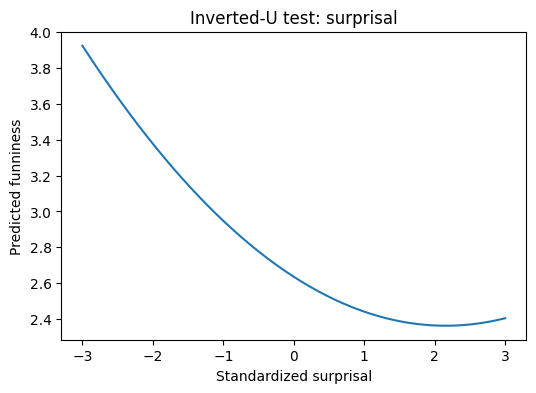

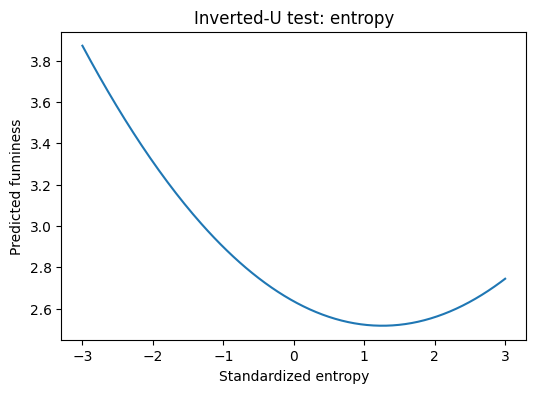

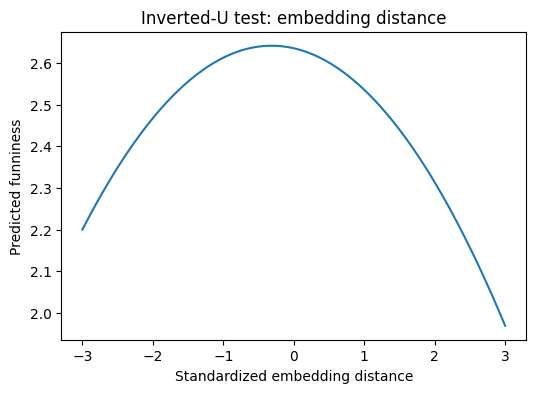

In [47]:
def plot_quadratic(feature_name, linear_name, quad_name):
    x = np.linspace(-3, 3, 200)
    b0 = model.params["const"]
    b1 = model.params[linear_name]
    b2 = model.params[quad_name]

    y_pred = b0 + b1*x + b2*x**2

    plt.figure(figsize=(6,4))
    plt.plot(x, y_pred)
    plt.xlabel(f"Standardized {feature_name}")
    plt.ylabel("Predicted funniness")
    plt.title(f"Inverted-U test: {feature_name}")
    plt.show()

plot_quadratic("surprisal", "S", "S2")
plot_quadratic("entropy", "H", "H2")
plot_quadratic("embedding distance", "D", "D2")

In [48]:
print("R^2:", model.rsquared)
print("Adjusted R^2:", model.rsquared_adj)

R^2: 0.04237853429889593
Adjusted R^2: 0.04045237647314781
